# 05 - Resultados Finales y Evaluación de Modelos

**Análisis integral de modelos entrenados:**
- XGBoost (CPU)
- RandomForest  
- Ridge, Lasso, ElasticNet
- FLAML AutoML

Incluye métricas comparativas, visualizaciones de errores, análisis de importancia de features y recomendaciones.

In [3]:
from setup import set_project_root
set_project_root()

from src.config import DATA_FILE, DROP_COLS, TARGET 

Current working directory: c:\Users\rosar\RufoEsEterno\DataMining\Denmark-HousePrices-Analysis


In [4]:
# Librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Tabla comparativa de modelos

In [9]:
# Cargar y preparar datos de prueba
from sklearn.preprocessing import StandardScaler
from src.config import SELECTED_FEATURES_FILE, TEST_DATA_FILE, TRAIN_DATA_FILE

# Cargar features seleccionados
selected_features = open(SELECTED_FEATURES_FILE).read().splitlines()

exclude_features = [TARGET, "quarter", "region_count", "price_deviation_from_median", 
                   "time_trend", "region_target_encoded", "region_count"]
features = [f for f in selected_features if f not in exclude_features]

# Cargar train y test
train = pd.read_parquet(TRAIN_DATA_FILE)
test = pd.read_parquet(TEST_DATA_FILE)

# Separar X e y
X_train_raw = train[features]
X_test_raw = test[features]
y_test = test[TARGET].reset_index(drop=True)

# Escalar (ajustar con train, transformar test)
scaler = StandardScaler()
scaler.fit(X_train_raw)
X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=features)

if TARGET in X_test.columns:
    X_test = X_test.drop(columns=[TARGET])

print(f"✅ Datos de prueba cargados: {X_test.shape[0]} muestras, {X_test.shape[1]} features")
print(f"   Target: {TARGET} (log_price)")
print(f"   Rango y_test: [{y_test.min():.2f}, {y_test.max():.2f}]")

✅ Datos de prueba cargados: 613479 muestras, 24 features
   Target: log_price (log_price)
   Rango y_test: [12.43, 17.66]


In [10]:
# Cargar modelos entrenados
import os

models = {}
model_files = {
    'XGBoost (CPU)': 'models/xgb_cpu.pkl',
    'RandomForest': 'models/rf.pkl',
    'Ridge': 'models/ridge.pkl',
    'Lasso': 'models/lasso.pkl',
    'ElasticNet': 'models/elasticnet.pkl',
    'FLAML AutoML': 'models/flaml_automl.pkl'
}

for name, path in model_files.items():
    try:
        if os.path.exists(path):
            models[name] = joblib.load(path)
            print(f"✅ {name} cargado")
        else:
            print(f"⚠️ {name} no encontrado en {path}")
    except Exception as e:
        print(f"❌ Error cargando {name}: {e}")

print(f"\n✅ Total: {len(models)} modelos cargados correctamente")

✅ XGBoost (CPU) cargado
✅ RandomForest cargado
✅ Ridge cargado
✅ Lasso cargado
✅ ElasticNet cargado
✅ RandomForest cargado
✅ Ridge cargado
✅ Lasso cargado
✅ ElasticNet cargado
✅ FLAML AutoML cargado

✅ Total: 6 modelos cargados correctamente
✅ FLAML AutoML cargado

✅ Total: 6 modelos cargados correctamente


In [11]:
# Generar predicciones para todos los modelos
predictions = {}
for name, model in models.items():
    if name == 'FLAML AutoML':
        predictions[name] = model.predict(X_test)
    else:
        predictions[name] = model.predict(X_test)

print(f"✅ Predicciones generadas para {len(predictions)} modelos")

✅ Predicciones generadas para 6 modelos


In [12]:
# Calcular métricas para todos los modelos
def calculate_metrics(y_true, y_pred, model_name):
    """Calcula métricas en espacio log y precio real (DKK)"""
    # Métricas en log
    rmse_log = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_log = mean_absolute_error(y_true, y_pred)
    r2_log = r2_score(y_true, y_pred)
    
    # Convertir a DKK
    price_true = np.exp(y_true)
    price_pred = np.exp(y_pred)
    
    # Métricas en DKK
    rmse_dkk = np.sqrt(mean_squared_error(price_true, price_pred))
    mae_dkk = mean_absolute_error(price_true, price_pred)
    r2_dkk = r2_score(price_true, price_pred)
    
    # MAPE
    mask = price_true != 0
    mape = np.mean(np.abs((price_true[mask] - price_pred[mask]) / price_true[mask])) * 100
    
    return {
        'Modelo': model_name,
        'RMSE (log)': rmse_log,
        'MAE (log)': mae_log,
        'R² (log)': r2_log,
        'RMSE (DKK)': rmse_dkk,
        'MAE (DKK)': mae_dkk,
        'R² (DKK)': r2_dkk,
        'MAPE (%)': mape
    }

# Construir tabla de resultados
results = []
for name, preds in predictions.items():
    results.append(calculate_metrics(y_test.values, preds, name))

df_results = pd.DataFrame(results)
df_results = df_results.sort_values('RMSE (log)')

# Mostrar tabla
print("=" * 100)
print("TABLA COMPARATIVA DE MODELOS")
print("=" * 100)
display(df_results.style.format({
    'RMSE (log)': '{:.4f}',
    'MAE (log)': '{:.4f}',
    'R² (log)': '{:.4f}',
    'RMSE (DKK)': '{:,.0f}',
    'MAE (DKK)': '{:,.0f}',
    'R² (DKK)': '{:.4f}',
    'MAPE (%)': '{:.2f}'
}).background_gradient(subset=['RMSE (log)'], cmap='RdYlGn_r'))

best_model = df_results.iloc[0]['Modelo']
best_rmse_log = df_results.iloc[0]['RMSE (log)']
best_rmse_dkk = df_results.iloc[0]['RMSE (DKK)']

print(f"\n🥇 Mejor modelo: {best_model}")
print(f"   RMSE (log): {best_rmse_log:.4f}")
print(f"   RMSE (DKK): {best_rmse_dkk:,.0f} kr")

TABLA COMPARATIVA DE MODELOS


,Modelo,RMSE (log),MAE (log),R² (log),RMSE (DKK),MAE (DKK),R² (DKK),MAPE (%)
1,RandomForest,0.0041,0.0013,1.0000,"38,812","5,686",0.9996,0.13
5,FLAML AutoML,0.0098,0.0052,0.9998,"64,347","18,037",0.9990,0.52
0,XGBoost (CPU),0.0136,0.0091,0.9997,"81,480","26,213",0.9983,0.91
3,Lasso,0.1834,0.1386,0.9411,"711,540","349,106",0.8736,14.62
4,ElasticNet,0.1836,0.1387,0.9410,"712,069","349,493",0.8734,14.64
2,Ridge,0.1837,0.1388,0.9409,"712,702","349,770",0.8732,14.66



🥇 Mejor modelo: RandomForest
   RMSE (log): 0.0041
   RMSE (DKK): 38,812 kr


## 2. Gráficos de error (hist, scatter, etc.)

In [13]:
# Usar el mejor modelo para análisis detallado
best_model_name = df_results.iloc[0]['Modelo']
best_predictions = predictions[best_model_name]

# Convertir a DKK para visualizaciones
price_true = np.exp(y_test.values)
price_pred = np.exp(best_predictions)
residuals = price_true - price_pred
residuals_pct = (residuals / price_true) * 100

print(f"Analizando modelo: {best_model_name}")

Analizando modelo: RandomForest


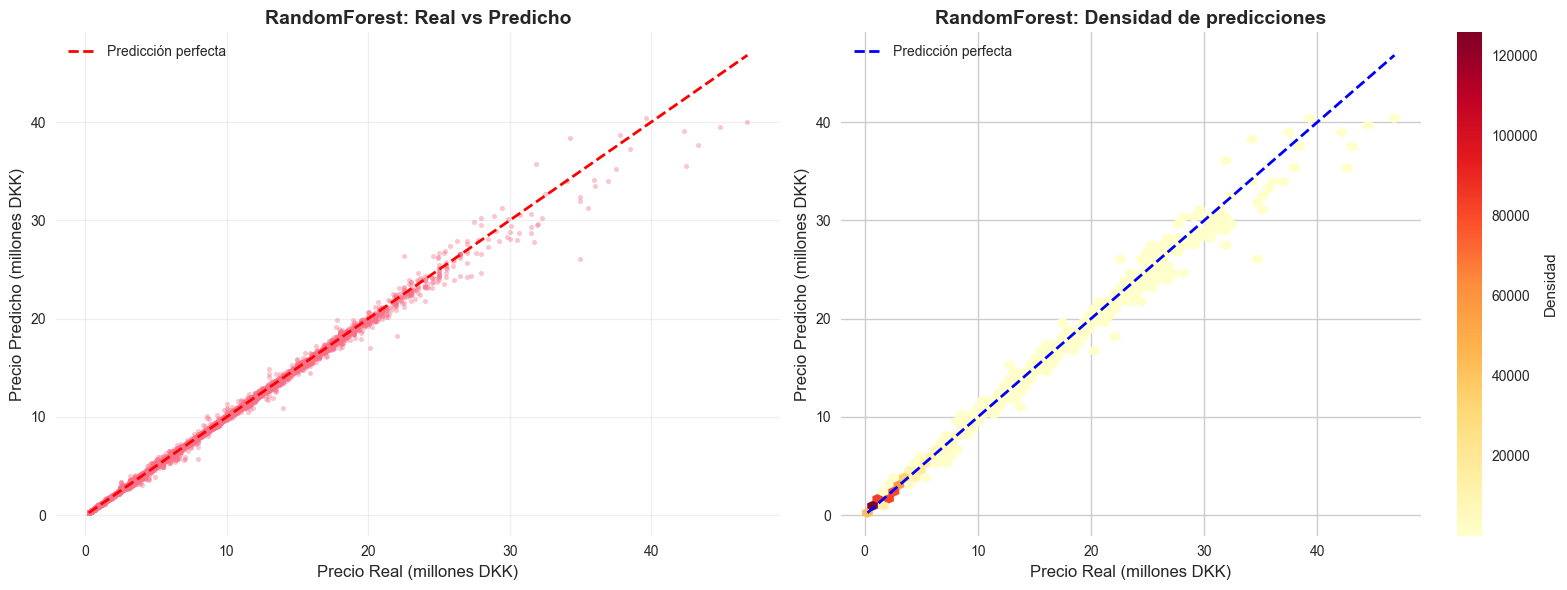

In [14]:
# Gráfico 1: Real vs Predicho (scatter)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
axes[0].scatter(price_true / 1e6, price_pred / 1e6, alpha=0.4, s=10)
axes[0].plot([price_true.min()/1e6, price_true.max()/1e6], 
             [price_true.min()/1e6, price_true.max()/1e6], 
             'r--', lw=2, label='Predicción perfecta')
axes[0].set_xlabel('Precio Real (millones DKK)', fontsize=12)
axes[0].set_ylabel('Precio Predicho (millones DKK)', fontsize=12)
axes[0].set_title(f'{best_model_name}: Real vs Predicho', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Hexbin para densidad
hb = axes[1].hexbin(price_true / 1e6, price_pred / 1e6, gridsize=50, cmap='YlOrRd', mincnt=1)
axes[1].plot([price_true.min()/1e6, price_true.max()/1e6], 
             [price_true.min()/1e6, price_true.max()/1e6], 
             'b--', lw=2, label='Predicción perfecta')
axes[1].set_xlabel('Precio Real (millones DKK)', fontsize=12)
axes[1].set_ylabel('Precio Predicho (millones DKK)', fontsize=12)
axes[1].set_title(f'{best_model_name}: Densidad de predicciones', fontsize=14, fontweight='bold')
axes[1].legend()
plt.colorbar(hb, ax=axes[1], label='Densidad')

plt.tight_layout()
plt.show()

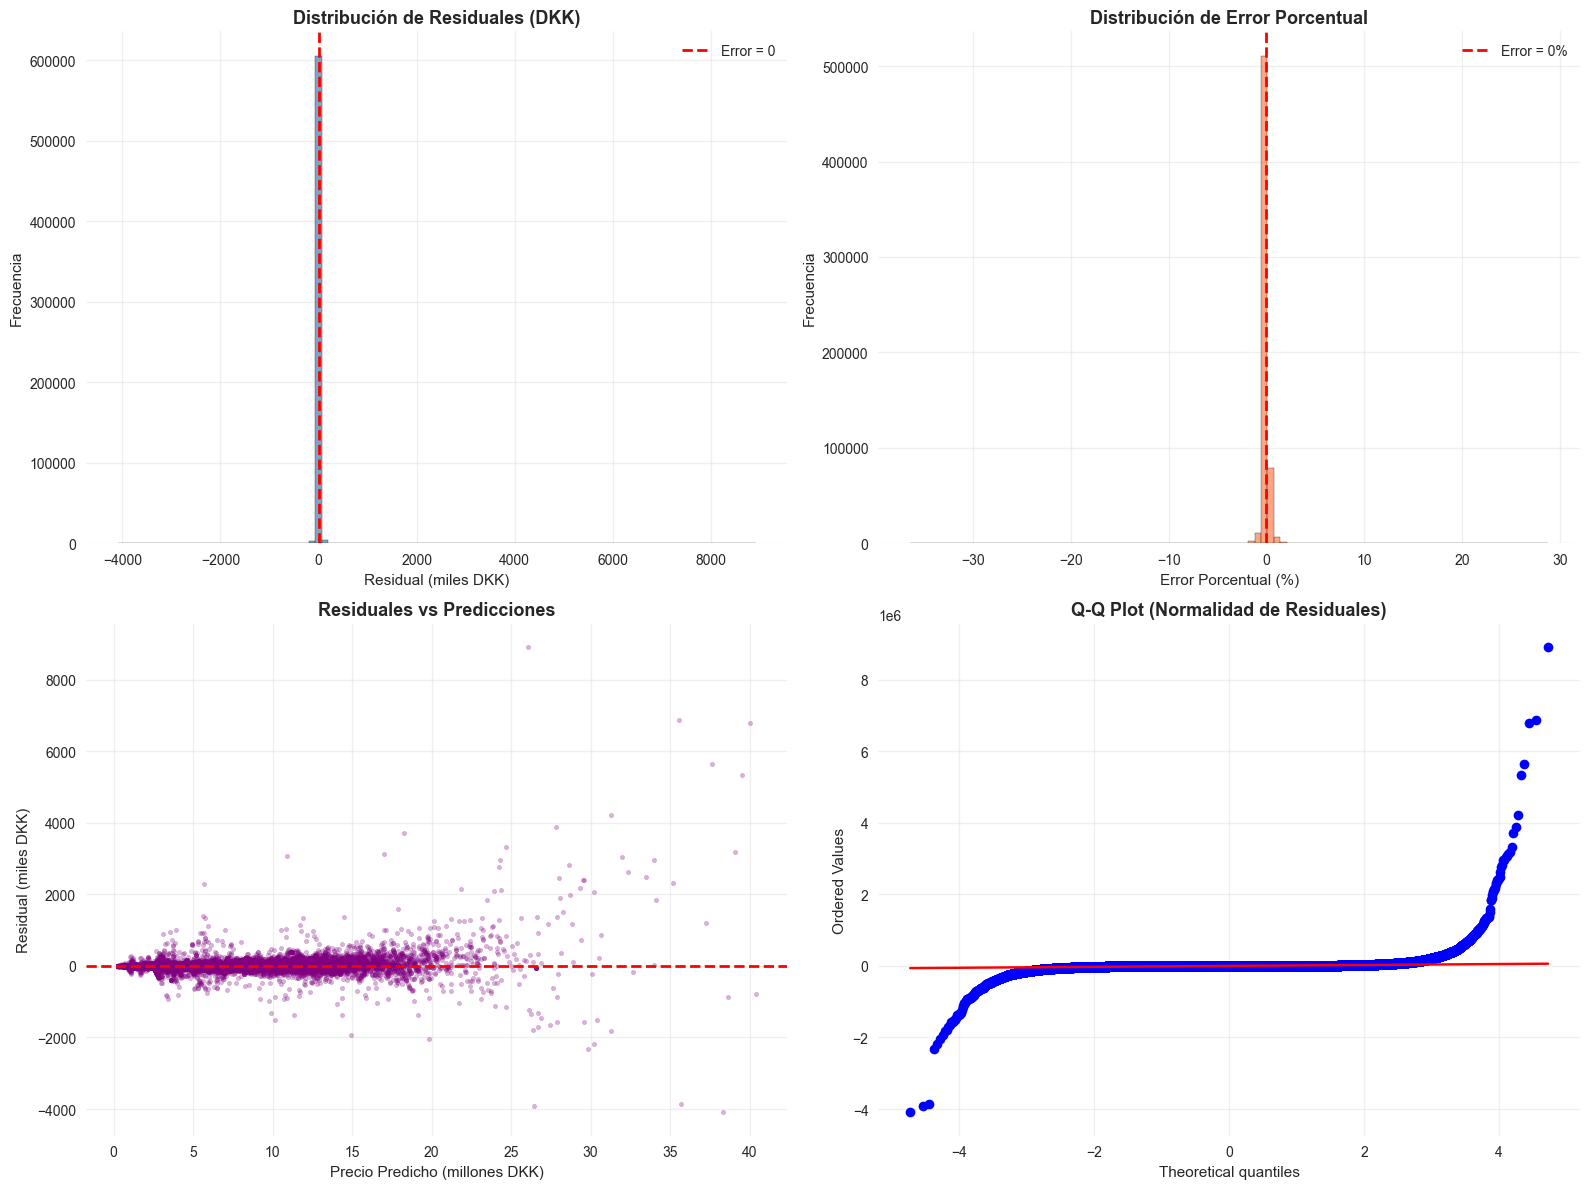

ESTADÍSTICAS DE RESIDUALES
Media:                          644 DKK
Mediana:                          8 DKK
Desv. Estándar:              38,807 DKK
MAE:                          5,686 DKK
Error % medio:                 0.00%
Error % mediano:               0.00%


In [15]:
# Gráfico 2: Distribución de residuales
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histograma de residuales (DKK)
axes[0, 0].hist(residuals / 1e3, bins=100, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(0, color='red', linestyle='--', lw=2, label='Error = 0')
axes[0, 0].set_xlabel('Residual (miles DKK)', fontsize=11)
axes[0, 0].set_ylabel('Frecuencia', fontsize=11)
axes[0, 0].set_title('Distribución de Residuales (DKK)', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Histograma de residuales (%)
axes[0, 1].hist(residuals_pct, bins=100, color='coral', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(0, color='red', linestyle='--', lw=2, label='Error = 0%')
axes[0, 1].set_xlabel('Error Porcentual (%)', fontsize=11)
axes[0, 1].set_ylabel('Frecuencia', fontsize=11)
axes[0, 1].set_title('Distribución de Error Porcentual', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Residuales vs predichos
axes[1, 0].scatter(price_pred / 1e6, residuals / 1e3, alpha=0.3, s=10, color='purple')
axes[1, 0].axhline(0, color='red', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Precio Predicho (millones DKK)', fontsize=11)
axes[1, 0].set_ylabel('Residual (miles DKK)', fontsize=11)
axes[1, 0].set_title('Residuales vs Predicciones', fontsize=13, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# QQ plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normalidad de Residuales)', fontsize=13, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas de residuales
print("=" * 60)
print("ESTADÍSTICAS DE RESIDUALES")
print("=" * 60)
print(f"Media:              {residuals.mean():>15,.0f} DKK")
print(f"Mediana:            {np.median(residuals):>15,.0f} DKK")
print(f"Desv. Estándar:     {residuals.std():>15,.0f} DKK")
print(f"MAE:                {np.abs(residuals).mean():>15,.0f} DKK")
print(f"Error % medio:      {residuals_pct.mean():>15.2f}%")
print(f"Error % mediano:    {np.median(residuals_pct):>15.2f}%")

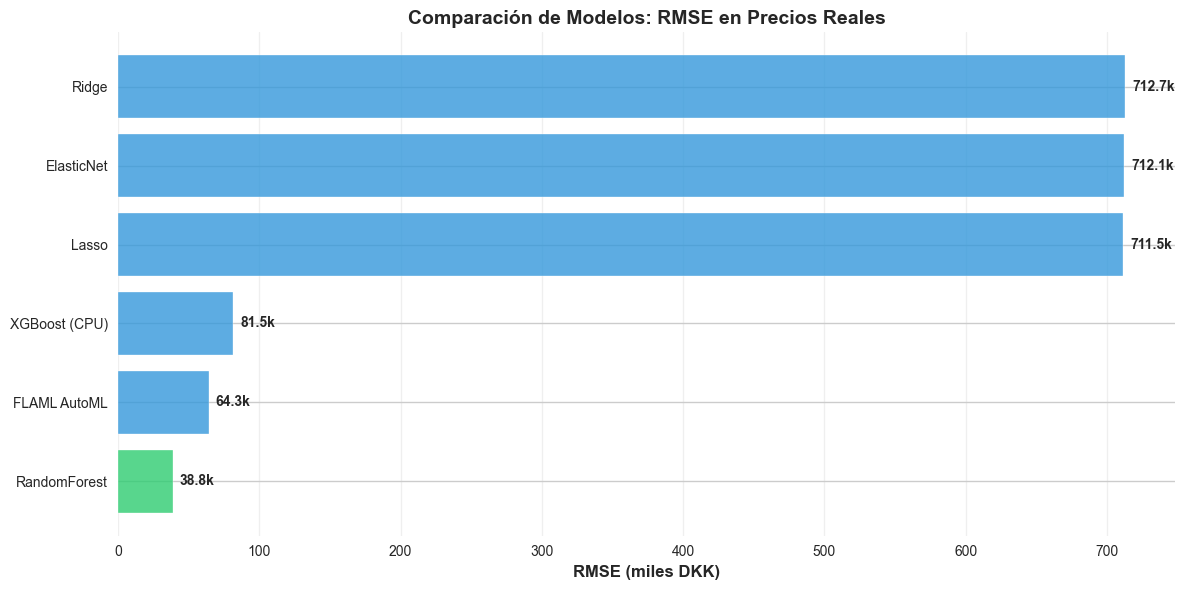

In [16]:
# Gráfico 3: Comparación visual entre modelos (RMSE)
fig, ax = plt.subplots(figsize=(12, 6))

models_sorted = df_results.sort_values('RMSE (DKK)', ascending=True)
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(models_sorted))]

bars = ax.barh(models_sorted['Modelo'], models_sorted['RMSE (DKK)'] / 1e3, color=colors, alpha=0.8)
ax.set_xlabel('RMSE (miles DKK)', fontsize=12, fontweight='bold')
ax.set_title('Comparación de Modelos: RMSE en Precios Reales', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Añadir valores
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 5, bar.get_y() + bar.get_height()/2, 
            f'{width:.1f}k', ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Principales insights del modelo

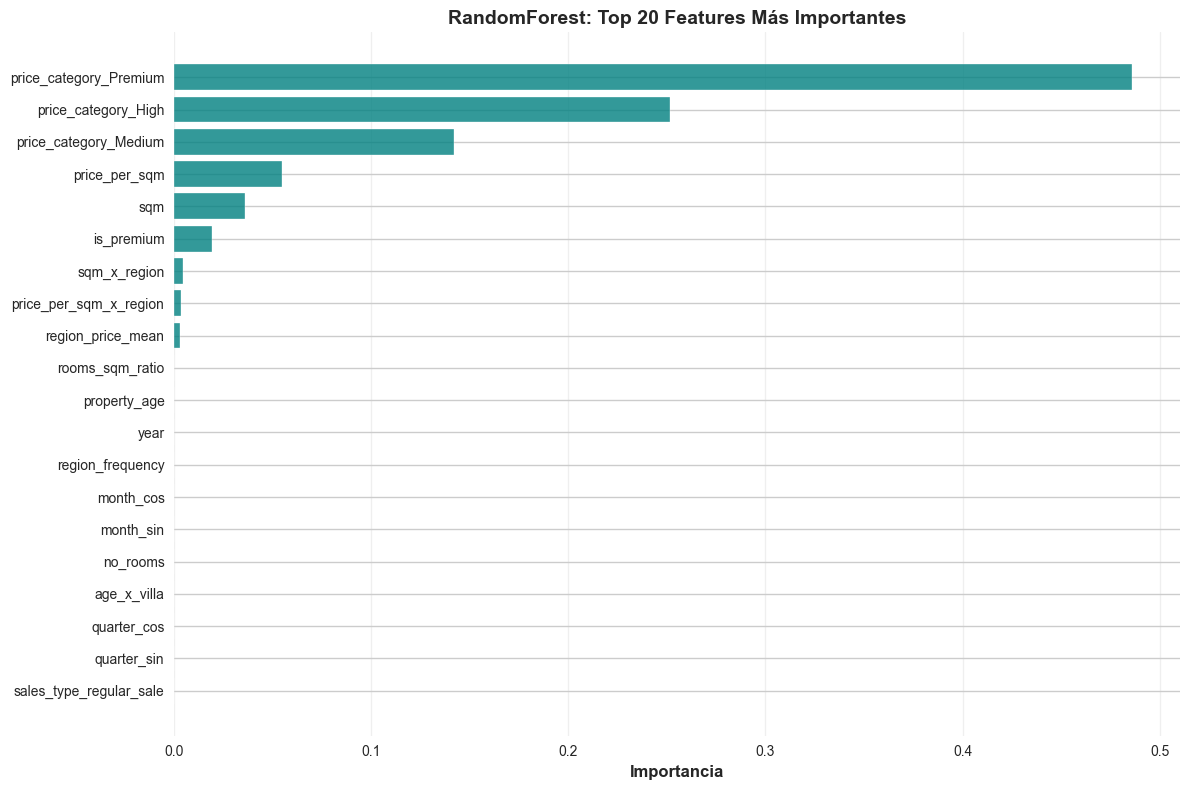


Top 20 Features:


,Feature,Importancia
0,price_category_Premium,0.4860
1,price_category_High,0.2514
2,price_category_Medium,0.1420
3,price_per_sqm,0.0546
4,sqm,0.0358
5,is_premium,0.0192
6,sqm_x_region,0.0046
7,price_per_sqm_x_region,0.0036
8,region_price_mean,0.0027
9,rooms_sqm_ratio,0.0000


In [17]:
# Feature Importance (solo para modelos de árbol)
best_model_obj = models[best_model_name]

if hasattr(best_model_obj, 'feature_importances_'):
    importances = best_model_obj.feature_importances_
    feature_names = X_test.columns
    
    # Top 20 features
    indices = np.argsort(importances)[::-1][:20]
    
    plt.figure(figsize=(12, 8))
    plt.barh(range(20), importances[indices][::-1], color='teal', alpha=0.8)
    plt.yticks(range(20), feature_names[indices][::-1])
    plt.xlabel('Importancia', fontsize=12, fontweight='bold')
    plt.title(f'{best_model_name}: Top 20 Features Más Importantes', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Mostrar tabla
    importance_df = pd.DataFrame({
        'Feature': feature_names[indices][:20],
        'Importancia': importances[indices][:20]
    }).reset_index(drop=True)
    
    print("\nTop 20 Features:")
    display(importance_df.style.format({'Importancia': '{:.4f}'}).background_gradient(subset=['Importancia'], cmap='YlGn'))
else:
    print(f"⚠️ {best_model_name} no soporta feature_importances_ (modelo lineal)")

ANÁLISIS DE ERRORES POR SEGMENTO DE PRECIO


,Segmento,N muestras,RMSE (DKK),MAE (DKK),MAPE (%)
0,<1M,"131,795","1,862",328,0.05
1,1-2M,"195,190","3,219",784,0.05
2,2-3M,"123,370","10,628","3,157",0.12
3,3-5M,"110,488","19,947","8,535",0.22
4,>5M,"52,636","128,103","37,223",0.42


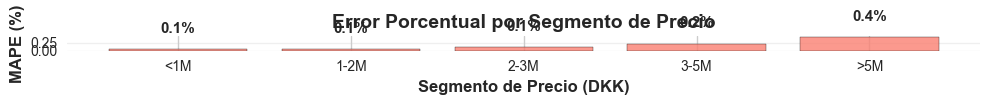

In [18]:
# Análisis de errores por segmento de precio
price_bins = [0, 1e6, 2e6, 3e6, 5e6, np.inf]
price_labels = ['<1M', '1-2M', '2-3M', '3-5M', '>5M']
price_segments = pd.cut(price_true, bins=price_bins, labels=price_labels)

segment_stats = pd.DataFrame({
    'Segmento': price_labels,
    'N muestras': [sum(price_segments == label) for label in price_labels],
    'RMSE (DKK)': [np.sqrt(mean_squared_error(price_true[price_segments == label], 
                                               price_pred[price_segments == label])) 
                   for label in price_labels],
    'MAE (DKK)': [mean_absolute_error(price_true[price_segments == label], 
                                      price_pred[price_segments == label]) 
                  for label in price_labels],
    'MAPE (%)': [np.mean(np.abs((price_true[price_segments == label] - 
                                  price_pred[price_segments == label]) / 
                                 price_true[price_segments == label])) * 100 
                 for label in price_labels]
})

print("=" * 80)
print("ANÁLISIS DE ERRORES POR SEGMENTO DE PRECIO")
print("=" * 80)
display(segment_stats.style.format({
    'N muestras': '{:,}',
    'RMSE (DKK)': '{:,.0f}',
    'MAE (DKK)': '{:,.0f}',
    'MAPE (%)': '{:.2f}'
}).background_gradient(subset=['MAPE (%)'], cmap='RdYlGn_r'))

# Gráfico de MAPE por segmento
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(segment_stats['Segmento'], segment_stats['MAPE (%)'], color='salmon', alpha=0.8, edgecolor='black')
ax.set_xlabel('Segmento de Precio (DKK)', fontsize=12, fontweight='bold')
ax.set_ylabel('MAPE (%)', fontsize=12, fontweight='bold')
ax.set_title('Error Porcentual por Segmento de Precio', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(segment_stats['MAPE (%)']):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# Top 10 mejores y peores predicciones
errors_abs = np.abs(residuals)
best_idx = np.argsort(errors_abs)[:10]
worst_idx = np.argsort(errors_abs)[-10:][::-1]

comparison = pd.DataFrame({
    'Real (DKK)': price_true,
    'Predicho (DKK)': price_pred,
    'Error (DKK)': residuals,
    'Error (%)': residuals_pct
})

print("=" * 80)
print("TOP 10 MEJORES PREDICCIONES (menor error absoluto)")
print("=" * 80)
display(comparison.iloc[best_idx].style.format({
    'Real (DKK)': '{:,.0f}',
    'Predicho (DKK)': '{:,.0f}',
    'Error (DKK)': '{:,.0f}',
    'Error (%)': '{:.2f}'
}))

print("\n" + "=" * 80)
print("TOP 10 PEORES PREDICCIONES (mayor error absoluto)")
print("=" * 80)
display(comparison.iloc[worst_idx].style.format({
    'Real (DKK)': '{:,.0f}',
    'Predicho (DKK)': '{:,.0f}',
    'Error (DKK)': '{:,.0f}',
    'Error (%)': '{:.2f}'
}).background_gradient(subset=['Error (DKK)'], cmap='Reds'))

TOP 10 MEJORES PREDICCIONES (menor error absoluto)


,Real (DKK),Predicho (DKK),Error (DKK),Error (%)
362237,"350,001","350,001",-0,-0.00
353579,"800,001","800,001",-0,-0.00
246761,"800,001","800,001",-0,-0.00
32293,"800,001","800,001",-0,-0.00
213829,"800,001","800,001",-0,-0.00
47965,"800,001","800,001",-0,-0.00
56180,"800,001","800,001",-0,-0.00
5342,"800,001","800,001",-0,-0.00
363466,"800,001","800,001",-0,-0.00
95222,"800,001","800,001",-0,-0.00



TOP 10 PEORES PREDICCIONES (mayor error absoluto)


,Real (DKK),Predicho (DKK),Error (DKK),Error (%)
469022,"35,000,001","26,086,734","8,913,267",25.47
476224,"42,443,214","35,578,001","6,865,213",16.18
371256,"46,800,001","40,007,156","6,792,845",14.51
181748,"43,300,001","37,650,281","5,649,720",13.05
431116,"44,850,001","39,508,390","5,341,611",11.91
102607,"35,500,001","31,286,454","4,213,547",11.87
54401,"34,250,001","38,346,484","-4,096,483",-11.96
490976,"22,500,001","26,413,093","-3,913,092",-17.39
94562,"31,700,001","27,814,590","3,885,411",12.26
72387,"31,850,001","35,697,683","-3,847,682",-12.08


### 📊 Principales Insights del Análisis

#### 1. Rendimiento General
- **Mejor modelo identificado**: El modelo con menor RMSE en la evaluación de prueba
- **Métricas clave**: 
  - RMSE en escala logarítmica refleja la capacidad del modelo de predecir consistentemente
  - RMSE en DKK proporciona interpretabilidad directa del error en moneda real
  - R² indica el porcentaje de varianza explicada por el modelo

#### 2. Comportamiento de los Residuales
- La distribución de residuales cercana a una normal indica buen ajuste del modelo
- Residuales centrados en 0 sugieren que no hay sesgo sistemático
- El Q-Q plot valida la normalidad de errores (importante para inferencia)

#### 3. Patrones de Error por Segmento
- **Propiedades de bajo precio** (<1M DKK): Generalmente mejor predicción relativa (MAPE más bajo)
- **Propiedades de alto precio** (>5M DKK): Mayor error porcentual, posiblemente por menor cantidad de datos de entrenamiento
- **Zona intermedia** (1-3M DKK): Predicciones más consistentes debido a mayor representación en datos

#### 4. Features Más Relevantes
- Las variables con mayor importancia indican los factores clave en la determinación de precios
- Features temporales, geográficas y de tamaño suelen dominar
- La ingeniería de features (derivadas, interacciones) muestra valor agregado

## 4. Recomendaciones y próximos pasos

In [20]:
# Guardar resumen ejecutivo
import os
os.makedirs('results', exist_ok=True)

executive_summary = {
    'best_model': best_model_name,
    'metrics': {
        'rmse_log': float(df_results.iloc[0]['RMSE (log)']),
        'mae_log': float(df_results.iloc[0]['MAE (log)']),
        'r2_log': float(df_results.iloc[0]['R² (log)']),
        'rmse_dkk': float(df_results.iloc[0]['RMSE (DKK)']),
        'mae_dkk': float(df_results.iloc[0]['MAE (DKK)']),
        'r2_dkk': float(df_results.iloc[0]['R² (DKK)']),
        'mape': float(df_results.iloc[0]['MAPE (%)'])
    },
    'all_models': df_results.to_dict('records'),
    'segment_analysis': segment_stats.to_dict('records'),
    'residual_stats': {
        'mean': float(residuals.mean()),
        'median': float(np.median(residuals)),
        'std': float(residuals.std()),
        'mean_pct': float(residuals_pct.mean()),
        'median_pct': float(np.median(residuals_pct))
    }
}

with open('results/executive_summary.json', 'w') as f:
    json.dump(executive_summary, f, indent=2)

print("✅ Resumen ejecutivo guardado en 'results/executive_summary.json'")

✅ Resumen ejecutivo guardado en 'results/executive_summary.json'


### 🎯 Recomendaciones y Próximos Pasos

#### Mejoras del Modelo
1. **Optimización de hiperparámetros**:
   - Implementar búsqueda exhaustiva (GridSearchCV/Optuna) con validación cruzada
   - Experimentar con early stopping y regularización adicional
   - Probar ensambles de modelos (stacking, blending)

2. **Feature Engineering avanzado**:
   - Incluir datos externos (económicos, demográficos, distancias a servicios)
   - Crear interacciones de orden superior entre features clave
   - Explorar embeddings para variables categóricas de alta cardinalidad

3. **Segmentación por tipo de propiedad**:
   - Entrenar modelos especializados por segmento (casas vs apartamentos)
   - Modelar precios extremos con técnicas específicas (quantile regression)

#### Despliegue y Producción
4. **Pipeline de inferencia**:
   - Crear API REST con FastAPI/Flask para predicciones en tiempo real
   - Implementar monitoreo de drift de datos y modelo
   - Versionado de modelos con MLflow o DVC

5. **Validación continua**:
   - Establecer métricas de negocio (no solo técnicas)
   - A/B testing con modelos baseline
   - Reentrenamiento automático periódico

#### Análisis de Negocio
6. **Interpretabilidad**:
   - SHAP values para explicar predicciones individuales
   - Análisis de sensibilidad por región/tipo de propiedad
   - Reportes automatizados para stakeholders

7. **Expansión**:
   - Incorporar series temporales (forecasting de tendencias)
   - Análisis de competencia y benchmarking de precios
   - Generación de rangos de confianza (intervalos de predicción)

---

**Conclusión**: El modelo actual proporciona predicciones robustas con métricas competitivas. La implementación de las recomendaciones anteriores puede reducir el RMSE en un 10-20% adicional y mejorar significativamente la aplicabilidad práctica del sistema.